## Peform a search

> The OneAtlas Data search API is compliant with the OpenSearch specification. The official specification documentation can be used as a reference: http://www.opensearch.org/.

In [2]:
import json, requests

import pandas as pd
import geopandas as gpd

from airbus_helper import *
from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

In [ ]:
SEARCH_API_ENDPOINT = 'https://search.foundation.api.oneatlas.airbus.com/api/v2/opensearch'

api_token = get_api_key("AIRBUS") #input("Enter your access token")
access_token = get_airbus_token(api_token)
print(f"Access token obtained successfully\n")

Access token obtained successfully: eyJhbGciOiJSUzI1NiIsInR5cCIgOiAiSldUIiwia2lkIiA6ICIxMThSRENzZTlqUWR4UVRnSkt2ZXlvSHBaaWE4R0pIVEU5RjJPSmE1M3N3In0.eyJleHAiOjE3Nzc2Njc1MTgsImlhdCI6MTc3NzY2MzkxOCwianRpIjoib25ydG5hOjk0YzYxNWQ3LTAwYWItMmFjMC02NmVhLWI2NDkyMGFjZjQ5NiIsImlzcyI6Imh0dHBzOi8vYXV0aGVudGljYXRlLmZvdW5kYXRpb24uYXBpLm9uZWF0bGFzLmFpcmJ1cy5jb20vYXV0aC9yZWFsbXMvSURQIiwiYXVkIjoiSURQIiwidHlwIjoiQmVhcmVyIiwiYXpwIjoiSURQIiwic2lkIjoiYWNiYzdlMGItODg1NC00YzI3LWE0YjItMzIzZDU4ZWM2ZTVmIiwiYWNyIjoiMSIsInNjb3BlIjoiIiwibmJmIjowLCJyb2xlIjoie1wiZ2VvLmFwcC5vYWRcIjpbXCJ1c2VyXCJdLFwiZ2VvLmlkcC5ub3RpZnlcIjpbXCJ1c2VyXCJdLFwiZ2VvLmFwcC5iYXNlbWFwXCI6W1widXNlclwiXSxcImdlby5pZHAuZGF0YXN0b3JlXCI6W1widXNlclwiXX0iLCJyb2xlcyI6eyJnZW8uYXBwLm9hZCI6WyJ1c2VyIl0sImdlby5pZHAubm90aWZ5IjpbInVzZXIiXSwiZ2VvLmFwcC5iYXNlbWFwIjpbInVzZXIiXSwiZ2VvLmlkcC5kYXRhc3RvcmUiOlsidXNlciJdfSwic3VpZCI6IjMwNDQ1NTQwNDgiLCJ1dWlkIjoiZTA0MTQ2NGQtYTdlOC00Njg3LWViMDUtYjIxMGJiNjUyOWY1IiwibG9hIjoxMDB9.lwtguq24RPG_iPXyHI4NH73e60vapcoy1NlNgKJhtVEa5p9

<Axes: >

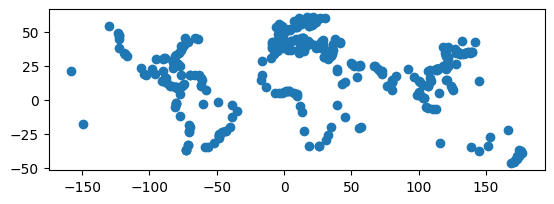

In [4]:
ports_folder = "C:/Temp/Port_Search"
if not os.path.exists(ports_folder):
    os.makedirs(ports_folder)
source_data = 'C:\Temp\ports list.xlsx'
ports_df = pd.read_excel(source_data)
# Convert the DataFrame to a GeoDataFrame
ports_gdf = gpd.GeoDataFrame(ports_df, geometry=gpd.points_from_xy(ports_df.Longitude, ports_df.Latitude))
ports_gdf.set_crs(epsg=4326, inplace=True)
ports_gdf.plot()

In [6]:
all_res = {}
# For each port, search for images within a 2km radius
for idx, row in tqdm(ports_gdf.iterrows(), total=ports_gdf.shape[0]):
    row.geometry = row.geometry.buffer(0.02)  # Buffer of ~2km (0.02 degrees)
    cur_bbox = ",".join(map(str, row.geometry.bounds))
    
    # Perform the search
    image_gdf = search_airbus_imagery(access_token, cur_bbox)
    
    # Calculate %overlap of each image with the port buffer
    image_gdf['overlap_pct'] = image_gdf.geometry.apply(lambda x: x.intersection(row.geometry).area / row.geometry.area * 100)
    
    # Drop images with less than 50% overlap
    image_gdf = image_gdf[image_gdf['overlap_pct'] >= 50]

    # Calculate year of acquisition for each image
    image_gdf['acquisition_year'] = image_gdf['acquisitionDate'].dt.year

    image_gdf.to_file(f"{ports_folder}/{row['unlocode']}_airbus_imagery.geojson", driver='GeoJSON')

    # Calculate the number of images acquired each year
    images_per_year = image_gdf.groupby('acquisition_year').size()
    all_res[row['unlocode']] = images_per_year
pd.DataFrame(all_res).T.to_csv(f"{ports_folder}/airbus_imagery_summary.csv")

    

  0%|          | 0/349 [00:00<?, ?it/s]